# Problem Statement

# Identify the factors contributing to train delays and cancellations and their impact on customer refund requests, in order to improve the punctuality of National Rail services and reduce the number of refund requests from January to April 2024.


# Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
import statistics
import pylab
import scipy.stats as stats

In [2]:
import pandas as pd

df = pd.read_csv(r'E:\Data Analyst Roadmap\Google Data Analytics Certificate Course\Different Analysis\UK Train Rides Dataset\Cleaning and Analysis in Python\railway.csv')


In [3]:
pd.set_option('display.max_columns',18)

In [4]:
df

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31648,1304623d-b8b7-4999-8e9c,2024-04-30,18:42:58,Online,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:00:00,20:30:00,20:30:00,On Time,NaN,No
31649,7da22246-f480-417c-bc2f,2024-04-30,18:46:10,Online,Contactless,NaN,Standard,Off-Peak,10,London Euston,Birmingham New Street,2024-04-30,20:15:00,21:35:00,21:35:00,On Time,NaN,No
31650,add9debf-46c1-4c75-b52d,2024-04-30,18:56:41,Station,Credit Card,NaN,Standard,Off-Peak,4,Manchester Piccadilly,Liverpool Lime Street,2024-04-30,20:15:00,20:45:00,20:45:00,On Time,NaN,No
31651,b92b047c-21fd-4859-966a,2024-04-30,19:51:47,Station,Credit Card,NaN,Standard,Off-Peak,10,London Euston,Birmingham New Street,2024-04-30,21:15:00,22:35:00,22:35:00,On Time,NaN,No


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31653 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       31653 non-null  object
 1   Date of Purchase     31653 non-null  object
 2   Time of Purchase     31653 non-null  object
 3   Purchase Type        31653 non-null  object
 4   Payment Method       31653 non-null  object
 5   Railcard             10735 non-null  object
 6   Ticket Class         31653 non-null  object
 7   Ticket Type          31653 non-null  object
 8   Price                31653 non-null  int64 
 9   Departure Station    31653 non-null  object
 10  Arrival Destination  31653 non-null  object
 11  Date of Journey      31653 non-null  object
 12  Departure Time       31653 non-null  object
 13  Arrival Time         31653 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       31653 non-null  object
 16  Reas

In [6]:
df['Reason for Delay'].unique()

array([nan, 'Signal Failure', 'Technical Issue', 'Weather Conditions',
       'Weather', 'Staffing', 'Staff Shortage', 'Signal failure',
       'Traffic'], dtype=object)

In [7]:
df['Reason for Delay']=df['Reason for Delay'].replace('Weather','Weather Conditions')
df['Reason for Delay']=df['Reason for Delay'].replace('Staffing','Staff Shortage')
df['Reason for Delay']=df['Reason for Delay'].replace('Signal failure','Signal Failure')

In [8]:
df['Reason for Delay'].unique()

array([nan, 'Signal Failure', 'Technical Issue', 'Weather Conditions',
       'Staff Shortage', 'Traffic'], dtype=object)

In [9]:
(df.isnull().sum()/31653)*100 

Transaction ID          0.000000
Date of Purchase        0.000000
Time of Purchase        0.000000
Purchase Type           0.000000
Payment Method          0.000000
Railcard               66.085363
Ticket Class            0.000000
Ticket Type             0.000000
Price                   0.000000
Departure Station       0.000000
Arrival Destination     0.000000
Date of Journey         0.000000
Departure Time          0.000000
Arrival Time            0.000000
Actual Arrival Time     5.939405
Journey Status          0.000000
Reason for Delay       86.819575
Refund Request          0.000000
dtype: float64

In [10]:
# Drop rows where 'Actual Arrival Time' is NaN
df = df.dropna(subset=['Actual Arrival Time'])

In [11]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,NaN,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,NaN,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,NaN,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [12]:
(df.isnull().sum()/31653)*100 

Transaction ID          0.000000
Date of Purchase        0.000000
Time of Purchase        0.000000
Purchase Type           0.000000
Payment Method          0.000000
Railcard               62.066787
Ticket Class            0.000000
Ticket Type             0.000000
Price                   0.000000
Departure Station       0.000000
Arrival Destination     0.000000
Date of Journey         0.000000
Departure Time          0.000000
Arrival Time            0.000000
Actual Arrival Time     0.000000
Journey Status          0.000000
Reason for Delay       86.819575
Refund Request          0.000000
dtype: float64

In [13]:
df['Railcard'].value_counts()

Railcard
Adult       4625
Disabled    2899
Senior      2603
Name: count, dtype: int64

In [14]:
df['Railcard'].mode()

0    Adult
Name: Railcard, dtype: object

In [15]:
df['Railcard'] = df['Railcard'].fillna('Adult')

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\3596928714.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Railcard'] = df['Railcard'].fillna('Adult')


In [16]:
(df.isnull().sum()/31653)*100 

Transaction ID          0.000000
Date of Purchase        0.000000
Time of Purchase        0.000000
Purchase Type           0.000000
Payment Method          0.000000
Railcard                0.000000
Ticket Class            0.000000
Ticket Type             0.000000
Price                   0.000000
Departure Station       0.000000
Arrival Destination     0.000000
Date of Journey         0.000000
Departure Time          0.000000
Arrival Time            0.000000
Actual Arrival Time     0.000000
Journey Status          0.000000
Reason for Delay       86.819575
Refund Request          0.000000
dtype: float64

In [17]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,NaN,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,NaN,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,NaN,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,Adult,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,NaN,No


In [18]:
df['Reason for Delay'].value_counts()

Reason for Delay
Weather Conditions    927
Technical Issue       472
Signal Failure        451
Staff Shortage        355
Traffic                87
Name: count, dtype: int64

In [19]:
df['Reason for Delay'] = df['Reason for Delay'].fillna('Unknown')

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\2454799981.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reason for Delay'] = df['Reason for Delay'].fillna('Unknown')


In [20]:
(df.isnull().sum()/31653)*100 

Transaction ID         0.0
Date of Purchase       0.0
Time of Purchase       0.0
Purchase Type          0.0
Payment Method         0.0
Railcard               0.0
Ticket Class           0.0
Ticket Type            0.0
Price                  0.0
Departure Station      0.0
Arrival Destination    0.0
Date of Journey        0.0
Departure Time         0.0
Arrival Time           0.0
Actual Arrival Time    0.0
Journey Status         0.0
Reason for Delay       0.0
Refund Request         0.0
dtype: float64

In [21]:
df.shape

(29773, 18)

In [22]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Unknown,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Unknown,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Unknown,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,Adult,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Unknown,No


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29773 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Transaction ID       29773 non-null  object
 1   Date of Purchase     29773 non-null  object
 2   Time of Purchase     29773 non-null  object
 3   Purchase Type        29773 non-null  object
 4   Payment Method       29773 non-null  object
 5   Railcard             29773 non-null  object
 6   Ticket Class         29773 non-null  object
 7   Ticket Type          29773 non-null  object
 8   Price                29773 non-null  int64 
 9   Departure Station    29773 non-null  object
 10  Arrival Destination  29773 non-null  object
 11  Date of Journey      29773 non-null  object
 12  Departure Time       29773 non-null  object
 13  Arrival Time         29773 non-null  object
 14  Actual Arrival Time  29773 non-null  object
 15  Journey Status       29773 non-null  object
 16  Reason fo

In [24]:
df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\3985058230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date of Purchase'] = pd.to_datetime(df['Date of Purchase'])
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\3985058230.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Date of Journey'] = pd.to_datetime(df['Date of Journey'])


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29773 entries, 0 to 31652
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Transaction ID       29773 non-null  object        
 1   Date of Purchase     29773 non-null  datetime64[ns]
 2   Time of Purchase     29773 non-null  object        
 3   Purchase Type        29773 non-null  object        
 4   Payment Method       29773 non-null  object        
 5   Railcard             29773 non-null  object        
 6   Ticket Class         29773 non-null  object        
 7   Ticket Type          29773 non-null  object        
 8   Price                29773 non-null  int64         
 9   Departure Station    29773 non-null  object        
 10  Arrival Destination  29773 non-null  object        
 11  Date of Journey      29773 non-null  datetime64[ns]
 12  Departure Time       29773 non-null  object        
 13  Arrival Time         29773 non-null 

In [26]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Unknown,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Unknown,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Unknown,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,Adult,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Unknown,No


In [27]:
df[['Journey Status','Reason for Delay']].head(50)

,Journey Status,Reason for Delay
0,On Time,Unknown
1,Delayed,Signal Failure
2,On Time,Unknown
3,On Time,Unknown
4,On Time,Unknown
5,On Time,Unknown
6,On Time,Unknown
7,On Time,Unknown
8,Delayed,Signal Failure
9,On Time,Unknown


In [28]:
df['Reason for Delay']=df['Reason for Delay'].replace('Unknown','Not Delayed')

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\3357875675.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Reason for Delay']=df['Reason for Delay'].replace('Unknown','Not Delayed')


In [29]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Not Delayed,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Not Delayed,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Not Delayed,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,Adult,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Not Delayed,No


In [30]:
df.drop_duplicates(inplace=True)

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\3006716147.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop_duplicates(inplace=True)


In [31]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Not Delayed,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Not Delayed,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Not Delayed,No
4,2be00b45-0762-485e-a7a3,2023-12-27,18:22:56,Online,Contactless,Adult,Standard,Advance,76,Liverpool Lime Street,London Euston,2024-01-01,16:45:00,19:00:00,19:00:00,On Time,Not Delayed,No


In [32]:
df['Purchase Type'].unique()

array(['Online', 'Station'], dtype=object)

In [33]:
df['Payment Method'].unique()

array(['Contactless', 'Credit Card', 'Debit Card'], dtype=object)

In [34]:
df['Railcard'].unique()

array(['Adult', 'Disabled', 'Senior'], dtype=object)

In [35]:
df['Ticket Class'].unique()

array(['Standard', 'First Class'], dtype=object)

In [36]:
df['Ticket Type'].unique()

array(['Advance', 'Off-Peak', 'Anytime'], dtype=object)

In [37]:
df['Price'].unique()

array([ 43,  23,   3,  13,  76,  35,   2,  37,   8,  15,   7,  86,  34,
        57,   5,  10,   4,  12,  33,  70,  16, 134,  29,  47,   6, 151,
        25,  21,  53,  19,   9,  20,  54,  17,  11,  84,  41, 200,  27,
        14, 107, 143,  22,  18,  78,  50,  32, 108,  72, 106,  65,  24,
        52,  67,  90,  31,  48,  59,  44,  95, 144, 114, 119,  38, 111,
        56, 128, 113,  80, 267,  63,  97,  26, 101,  36, 216,  93,  30,
        82,  88,  71,  55, 126, 110,  89,  51,  66, 168, 235,  69, 162,
         1, 118, 135,  28,  45, 129,  73,  42,  49, 176,  39, 180, 157,
       121,  77, 211, 104, 112,  96, 171, 146, 154,  64, 116, 158, 242,
       117, 178, 203, 238,  74, 109,  94, 102])

In [38]:
df['Departure Station'].unique()

array(['London Paddington', 'London Kings Cross', 'Liverpool Lime Street',
       'London Euston', 'York', 'Manchester Piccadilly',
       'Birmingham New Street', 'London St Pancras', 'Oxford', 'Reading',
       'Edinburgh Waverley', 'Bristol Temple Meads'], dtype=object)

In [39]:
df['Arrival Destination'].unique()

array(['Liverpool Lime Street', 'York', 'Manchester Piccadilly',
       'Reading', 'London Euston', 'Oxford', 'Durham',
       'London St Pancras', 'Birmingham New Street', 'London Paddington',
       'Bristol Temple Meads', 'Tamworth', 'London Waterloo', 'Sheffield',
       'Wolverhampton', 'Leeds', 'Stafford', 'Doncaster', 'Swindon',
       'Nottingham', 'Peterborough', 'Edinburgh', 'Crewe',
       'London Kings Cross', 'Leicester', 'Nuneaton', 'Didcot',
       'Edinburgh Waverley', 'Coventry', 'Wakefield', 'Cardiff Central',
       'Warrington'], dtype=object)

In [40]:
df['Departure Time'].unique()

array(['11:00:00', '09:45:00', '18:15:00', '21:30:00', '16:45:00',
       '06:15:00', '22:30:00', '00:00:00', '01:30:00', '01:45:00',
       '02:15:00', '04:15:00', '05:00:00', '06:30:00', '07:45:00',
       '07:30:00', '09:00:00', '11:15:00', '10:30:00', '09:30:00',
       '12:45:00', '13:15:00', '13:45:00', '14:15:00', '15:00:00',
       '16:30:00', '17:00:00', '17:45:00', '18:45:00', '23:30:00',
       '02:45:00', '04:30:00', '05:30:00', '06:00:00', '03:30:00',
       '06:45:00', '08:00:00', '08:15:00', '08:45:00', '09:15:00',
       '11:45:00', '15:30:00', '16:00:00', '17:15:00', '18:30:00',
       '18:00:00', '19:15:00', '20:15:00', '00:30:00', '02:00:00',
       '02:30:00', '23:45:00', '00:15:00', '03:15:00', '05:15:00',
       '05:45:00', '03:00:00', '04:00:00', '07:15:00', '08:30:00',
       '10:45:00', '12:00:00', '13:30:00', '14:30:00', '15:15:00',
       '15:45:00', '16:15:00', '14:45:00', '19:00:00', '19:30:00',
       '17:30:00', '19:45:00', '20:00:00', '22:00:00', '22:15:

In [41]:
df['Journey Status'].unique()

array(['On Time', 'Delayed'], dtype=object)

In [42]:
df['Reason for Delay'].unique()

array(['Not Delayed', 'Signal Failure', 'Technical Issue',
       'Weather Conditions', 'Staff Shortage', 'Traffic'], dtype=object)

In [43]:
df['Refund Request'].unique()

array(['No', 'Yes'], dtype=object)

# Statistical Analysis

In [44]:
df.describe()

,Date of Purchase,Price,Date of Journey
count,29773,29773.000000,29773
mean,2024-02-28 15:01:29.597958144,23.392503,2024-03-01 06:48:06.722869760
min,2023-12-08 00:00:00,1.000000,2024-01-01 00:00:00
25%,2024-01-30 00:00:00,5.000000,2024-01-31 00:00:00
50%,2024-02-29 00:00:00,11.000000,2024-03-01 00:00:00
75%,2024-03-31 00:00:00,35.000000,2024-03-31 00:00:00
max,2024-04-30 00:00:00,267.000000,2024-04-30 00:00:00
std,NaN,29.949671,NaN


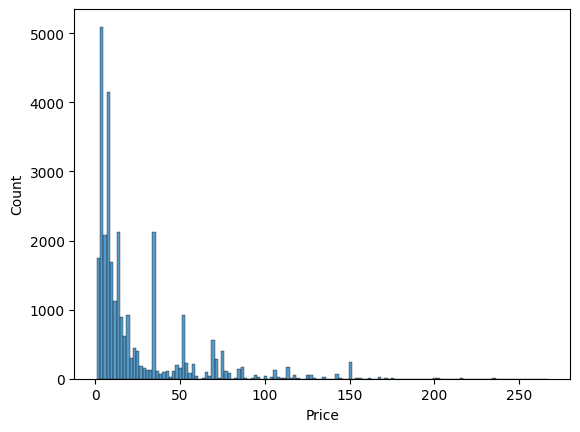

In [45]:
for i in df.select_dtypes('number').columns:
    sns.histplot(data=df,x=i)
    plt.show()

In [46]:
df['Price'].mean()

np.float64(23.392503274779163)

In [47]:
df['Price'].median()

np.float64(11.0)

In [48]:
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 -Q1
Upper_bound = Q1+(1.5*IQR)
Lower_bound = Q1-(1.5*IQR)
df = df[(df['Price']>Lower_bound)&(df['Price']<Upper_bound)]

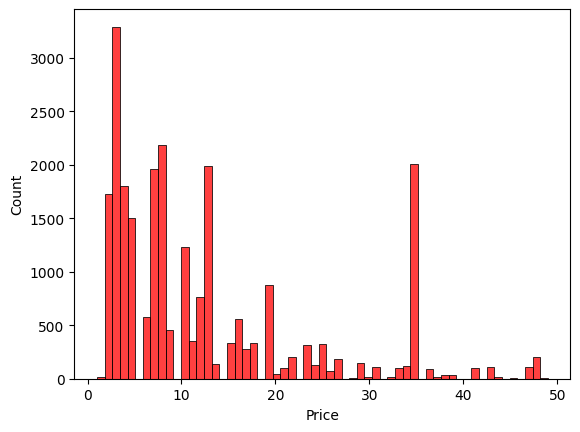

In [49]:
for i in df.select_dtypes('number').columns:
    sns.histplot(data=df,x=i,color='red')
    plt.show()

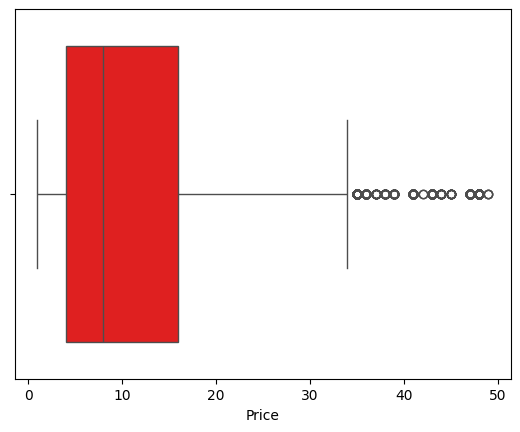

In [50]:
for i in df.select_dtypes('number').columns:
    sns.boxplot(data=df,x=i,color='red')
    plt.show()

In [51]:
df['Ticket Class'].unique()

array(['Standard', 'First Class'], dtype=object)

In [52]:
df['Price'].mean()

np.float64(12.495622626424145)

In [53]:
df['Price'].median()

np.float64(8.0)

In [54]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Not Delayed,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Not Delayed,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Not Delayed,No
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,08:05:00,08:05:00,On Time,Not Delayed,No


In [55]:
df.shape

(25015, 18)

In [56]:
(df['Refund Request'].value_counts()/25015)*100

Refund Request
No     98.940636
Yes     1.059364
Name: count, dtype: float64

In [57]:
df['Refund Request'].value_counts()

Refund Request
No     24750
Yes      265
Name: count, dtype: int64

In [58]:
df['Reason for Delay'].value_counts()

Reason for Delay
Not Delayed           23832
Signal Failure          391
Technical Issue         264
Staff Shortage          253
Weather Conditions      243
Traffic                  32
Name: count, dtype: int64

In [59]:
Delayed = df['Journey Status'].value_counts()

In [60]:
Delayed

Journey Status
On Time    23832
Delayed     1183
Name: count, dtype: int64

([<matplotlib.patches.Wedge at 0x21609b98950>,
 [Text(-1.0878819888286462, 0.16282744971972482, 'On Time'),
  Text(1.3845770948080531, -0.2072348149633445, 'Delayed')],
 [Text(-0.593390175724716, 0.08881497257439536, '95.3%'),
  Text(0.8900852752337485, -0.13322238104786432, '4.7%')])

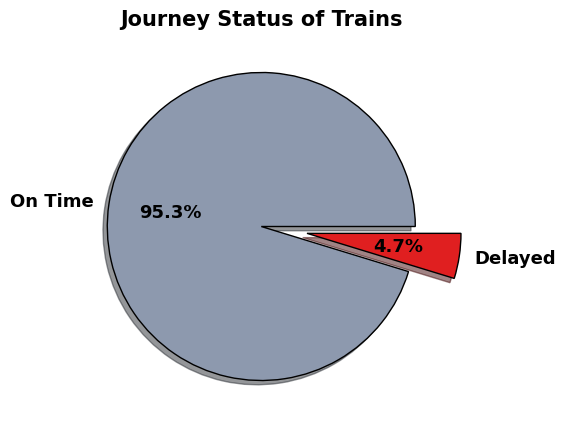

In [61]:
explode_list = [0,0.3]
Colors = ['#8d99ae','#e01f20']
plt.figure(figsize=(5,5))
plt.title('Journey Status of Trains',fontdict=({'fontsize':15,'fontweight':'bold'}))
plt.pie(Delayed.values,labels=Delayed.index,shadow=True,explode=explode_list,autopct='%1.1f%%',wedgeprops=({'edgecolor':'black'}),colors=Colors,textprops=({'fontsize':13,'color':'black','fontweight':'bold'}))

In [62]:
Reason = df[df['Reason for Delay']!='Not Delayed']

In [63]:
Reason = Reason.groupby('Reason for Delay').agg({'Transaction ID':'count'}).reset_index()

In [64]:
Reason_Of_Delay = Reason['Reason for Delay']
Count = Reason['Transaction ID']

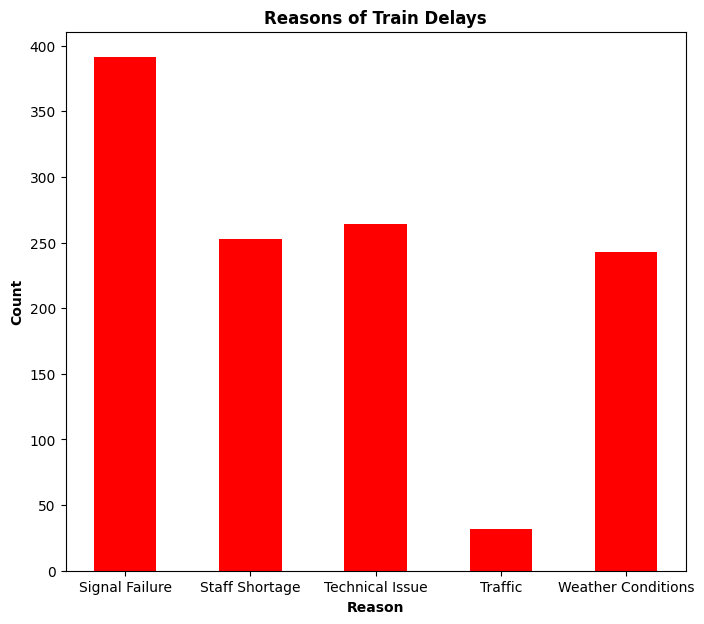

In [65]:
plt.figure(figsize=(8,7))
Colors = ['#b93234','#b93234','#b93234','#b93234','#b93234']
plt.bar(Reason_Of_Delay,Count,color='red',label=Reason_Of_Delay.values,width=0.5)
plt.title('Reasons of Train Delays',fontdict=({'fontweight':'bold'}))
plt.xlabel('Reason',fontdict=({'fontweight':'bold'}))
plt.ylabel('Count',fontdict=({'fontweight':'bold'}))
plt.show()

In [66]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Not Delayed,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Not Delayed,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Not Delayed,No
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,08:05:00,08:05:00,On Time,Not Delayed,No


In [67]:
Journey_By_Price = df.groupby('Journey Status').agg({'Price':'mean'}).reset_index()

In [68]:
Journey_By_Price

,Journey Status,Price
0,Delayed,11.096365
1,On Time,12.565081


In [69]:
Journey_Status_Price = Journey_By_Price['Journey Status']
Average_Price = Journey_By_Price['Price']

Text(0.5, 0, 'Journey Status')

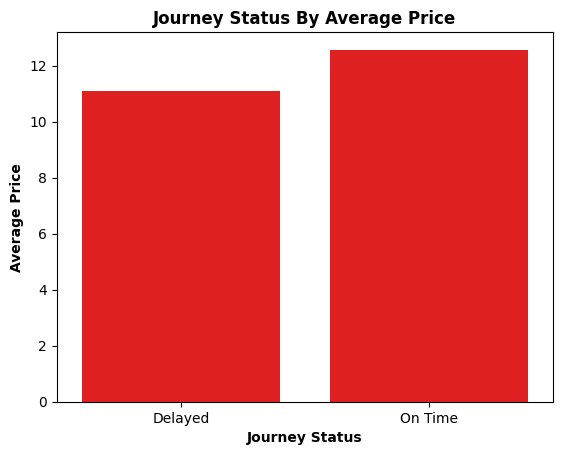

In [70]:
sns.barplot(x=Journey_Status_Price,y=Average_Price,color='red')
plt.title('Journey Status By Average Price',fontdict=({'fontweight':'bold'}))
plt.ylabel('Average Price',fontdict=({'fontweight':'bold'}))
plt.xlabel('Journey Status',fontdict=({'fontweight':'bold'}))

In [71]:
Refund_Request  = df.groupby('Refund Request').agg({'Price':'mean'}).reset_index()

In [72]:
Refund_Request

,Refund Request,Price
0,No,12.475596
1,Yes,14.366038


In [73]:
Refund_Request_Price = Refund_Request['Refund Request']
Average_Price = Refund_Request['Price']
print(Refund_Request)

  Refund Request      Price
0             No  12.475596
1            Yes  14.366038


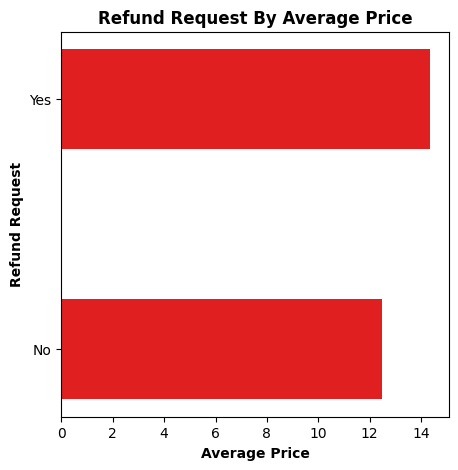

In [74]:
plt.figure(figsize=(5,5))
plt.barh(Refund_Request_Price,Average_Price,color='#e01f20',height=0.4)
plt.title('Refund Request By Average Price',fontdict=({'fontweight':'bold'}))
plt.ylabel('Refund Request',fontdict=({'fontweight':'bold'}))
plt.xlabel('Average Price',fontdict=({'fontweight':'bold'}))
plt.show()

In [75]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,13:30:00,13:30:00,On Time,Not Delayed,No
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,11:35:00,11:40:00,Delayed,Signal Failure,No
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,18:45:00,18:45:00,On Time,Not Delayed,No
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,22:30:00,22:30:00,On Time,Not Delayed,No
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,08:05:00,08:05:00,On Time,Not Delayed,No


In [76]:
df['Arrival Time'] = pd.to_datetime(df['Arrival Time'])
df['Actual Arrival Time'] = pd.to_datetime(df['Actual Arrival Time'])

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\1220007609.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Arrival Time'] = pd.to_datetime(df['Arrival Time'])
C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\1220007609.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Actual Arrival Time'] = pd.to_datetime(df['Actual Arrival Time'])


In [77]:
df['Train Time Difference'] = df['Actual Arrival Time'] - df['Arrival Time']

In [78]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,...,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Train Time Difference
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,...,Liverpool Lime Street,2024-01-01,11:00:00,2024-08-05 13:30:00,2024-08-05 13:30:00,On Time,Not Delayed,No,0 days 00:00:00
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,...,York,2024-01-01,09:45:00,2024-08-05 11:35:00,2024-08-05 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,...,Manchester Piccadilly,2024-01-02,18:15:00,2024-08-05 18:45:00,2024-08-05 18:45:00,On Time,Not Delayed,No,0 days 00:00:00
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,...,Reading,2024-01-01,21:30:00,2024-08-05 22:30:00,2024-08-05 22:30:00,On Time,Not Delayed,No,0 days 00:00:00
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,...,York,2024-01-01,06:15:00,2024-08-05 08:05:00,2024-08-05 08:05:00,On Time,Not Delayed,No,0 days 00:00:00


In [79]:
df['Train Time Difference'].unique()

<TimedeltaArray>
['0 days 00:00:00', '0 days 00:05:00', '0 days 00:17:00', '0 days 00:31:00',
 '0 days 00:24:00', '0 days 00:30:00', '0 days 00:59:00', '0 days 02:54:00',
 '0 days 00:37:00', '0 days 00:32:00',
 ...
 '0 days 02:45:00', '0 days 01:28:00', '0 days 01:38:00', '0 days 01:07:00',
 '0 days 02:53:00', '0 days 02:50:00', '0 days 02:05:00', '0 days 02:21:00',
 '0 days 01:25:00', '0 days 02:49:00']
Length: 133, dtype: timedelta64[ns]

In [80]:
df['Train Time Difference Hours']=df['Train Time Difference'].dt.total_seconds()/3600

In [81]:
df['Train Time Difference minutes']=df['Train Time Difference'].dt.total_seconds()/60

In [82]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,...,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Train Time Difference,Train Time Difference Hours,Train Time Difference minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,...,11:00:00,2024-08-05 13:30:00,2024-08-05 13:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.000000,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,...,09:45:00,2024-08-05 11:35:00,2024-08-05 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,0.083333,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,...,18:15:00,2024-08-05 18:45:00,2024-08-05 18:45:00,On Time,Not Delayed,No,0 days 00:00:00,0.000000,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,...,21:30:00,2024-08-05 22:30:00,2024-08-05 22:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.000000,0.0
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,...,06:15:00,2024-08-05 08:05:00,2024-08-05 08:05:00,On Time,Not Delayed,No,0 days 00:00:00,0.000000,0.0


In [83]:
df['Train Time Difference Hours']=round(df['Train Time Difference Hours'],2)

In [84]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,...,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Train Time Difference,Train Time Difference Hours,Train Time Difference minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,...,11:00:00,2024-08-05 13:30:00,2024-08-05 13:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,...,09:45:00,2024-08-05 11:35:00,2024-08-05 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,0.08,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,...,18:15:00,2024-08-05 18:45:00,2024-08-05 18:45:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,...,21:30:00,2024-08-05 22:30:00,2024-08-05 22:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,...,06:15:00,2024-08-05 08:05:00,2024-08-05 08:05:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0


In [85]:
Refund_Request = df.groupby('Refund Request').agg({'Train Time Difference minutes':'mean'}).reset_index()

In [86]:
Refund_Request

,Refund Request,Train Time Difference minutes
0,No,2.173697
1,Yes,23.233962


In [87]:
Refund_Request_Yes_No = Refund_Request['Refund Request']
Traing_AVG_Arrival_Delayed_Minutes = Refund_Request['Train Time Difference minutes']

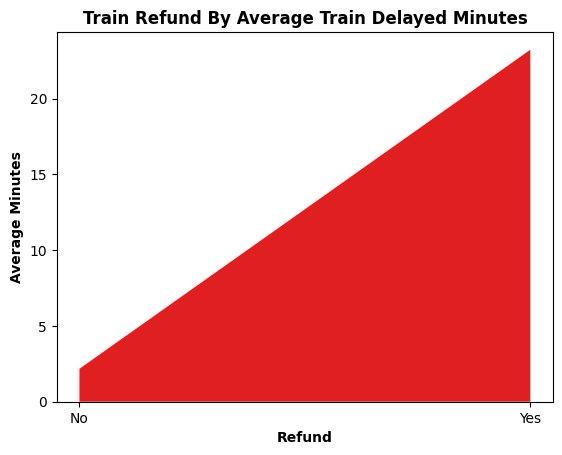

In [88]:
plt.stackplot(Refund_Request_Yes_No,Traing_AVG_Arrival_Delayed_Minutes,colors=['#e01f20'])
plt.title('Train Refund By Average Train Delayed Minutes',fontdict=({'fontweight':'bold'}))
plt.ylabel('Average Minutes',fontdict=({'fontweight':'bold'}))
plt.xlabel('Refund',fontdict=({'fontweight':'bold'}))
plt.show()

In [89]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,...,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Train Time Difference,Train Time Difference Hours,Train Time Difference minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,...,11:00:00,2024-08-05 13:30:00,2024-08-05 13:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,...,09:45:00,2024-08-05 11:35:00,2024-08-05 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,0.08,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,...,18:15:00,2024-08-05 18:45:00,2024-08-05 18:45:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,...,21:30:00,2024-08-05 22:30:00,2024-08-05 22:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,...,06:15:00,2024-08-05 08:05:00,2024-08-05 08:05:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0


In [90]:
Payment_Method = df['Payment Method'].value_counts()

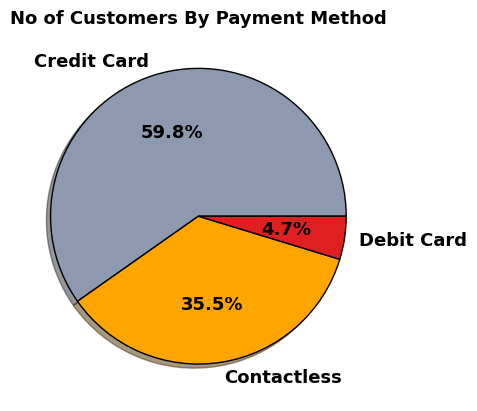

In [91]:
Colors = ['#8d99ae','orange','#e01f20']
plt.title('No of Customers By Payment Method',fontdict=({'fontsize':13,'fontweight':'bold'}))
plt.pie(Payment_Method.values,labels=Payment_Method.index,autopct='%1.1f%%',colors=Colors,shadow=True,wedgeprops=({'edgecolor':'black'}),textprops=({'fontsize':13,'color':'black','fontweight':'bold'}))
plt.show()

In [92]:
df['Railcard'].value_counts()

Railcard
Adult       19740
Disabled     2758
Senior       2517
Name: count, dtype: int64

In [93]:
Purchase_Type = df['Purchase Type'].value_counts()

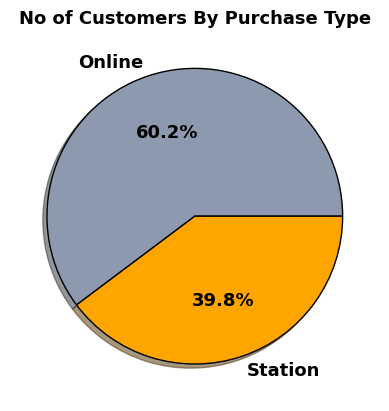

In [94]:
Colors = ['#8d99ae','orange']
plt.title('No of Customers By Purchase Type',fontdict=({'fontsize':13,'fontweight':'bold'}))
plt.pie(Purchase_Type.values,labels=Purchase_Type.index,autopct='%1.1f%%',colors=Colors,shadow=True,wedgeprops=({'edgecolor':'black'}),textprops=({'fontsize':13,'color':'black','fontweight':'bold'}))
plt.show()

In [95]:
pd.set_option('display.max_columns',25)

In [96]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Train Time Difference,Train Time Difference Hours,Train Time Difference minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,2024-08-05 13:30:00,2024-08-05 13:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,2024-08-05 11:35:00,2024-08-05 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,0.08,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,2024-08-05 18:45:00,2024-08-05 18:45:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,2024-08-05 22:30:00,2024-08-05 22:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,2024-08-05 08:05:00,2024-08-05 08:05:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0


# Hypothesis Testing

# Average Price Differnece By Ticket Class

In [97]:
df['Ticket Class'].unique()

array(['Standard', 'First Class'], dtype=object)

In [98]:
Standard_Ticket = df[df['Ticket Class']=='Standard']['Price']
print(Standard_Ticket.mean())

11.96997188857654


In [99]:
First_Class_Ticket = df[df['Ticket Class']=='First Class']['Price']
print(First_Class_Ticket.mean())

20.52504879635654


In [100]:
t_test,p_value = stats.ttest_ind(Standard_Ticket,First_Class_Ticket)
print(p_value)

2.421565869362596e-196


In [101]:
if(p_value<0.05):
    print('There is a Difference Between Mean Price of Standard and FirstClass Ticker')
else:
  print('There is No Difference Between Mean Price of Standard and FirstClass Ticker')

There is a Difference Between Mean Price of Standard and FirstClass Ticker


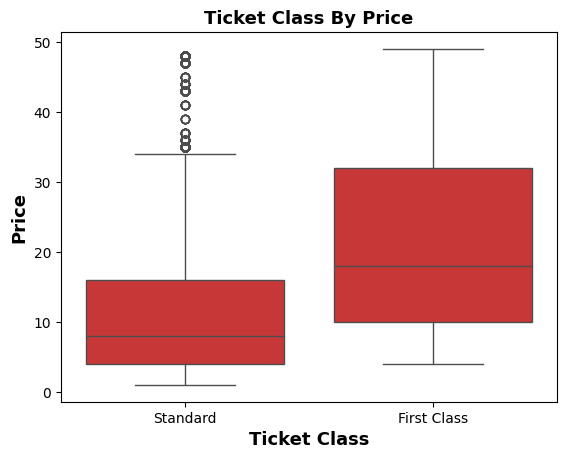

In [102]:
sns.boxplot(x='Ticket Class',y='Price',data=df,color='#e01f20')
plt.title('Ticket Class By Price',fontdict=({'fontsize':13,'fontweight':'bold'}))
plt.xlabel('Ticket Class',fontdict=({'fontsize':13,'fontweight':'bold'}))
plt.ylabel('Price',fontdict=({'fontsize':13,'fontweight':'bold'}))
plt.show()

In [103]:
df.head()

,Transaction ID,Date of Purchase,Time of Purchase,Purchase Type,Payment Method,Railcard,Ticket Class,Ticket Type,Price,Departure Station,Arrival Destination,Date of Journey,Departure Time,Arrival Time,Actual Arrival Time,Journey Status,Reason for Delay,Refund Request,Train Time Difference,Train Time Difference Hours,Train Time Difference minutes
0,da8a6ba8-b3dc-4677-b176,2023-12-08,12:41:11,Online,Contactless,Adult,Standard,Advance,43,London Paddington,Liverpool Lime Street,2024-01-01,11:00:00,2024-08-05 13:30:00,2024-08-05 13:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
1,b0cdd1b0-f214-4197-be53,2023-12-16,11:23:01,Station,Credit Card,Adult,Standard,Advance,23,London Kings Cross,York,2024-01-01,09:45:00,2024-08-05 11:35:00,2024-08-05 11:40:00,Delayed,Signal Failure,No,0 days 00:05:00,0.08,5.0
2,f3ba7a96-f713-40d9-9629,2023-12-19,19:51:27,Online,Credit Card,Adult,Standard,Advance,3,Liverpool Lime Street,Manchester Piccadilly,2024-01-02,18:15:00,2024-08-05 18:45:00,2024-08-05 18:45:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
3,b2471f11-4fe7-4c87-8ab4,2023-12-20,23:00:36,Station,Credit Card,Adult,Standard,Advance,13,London Paddington,Reading,2024-01-01,21:30:00,2024-08-05 22:30:00,2024-08-05 22:30:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0
5,4e1dcd88-3d95-44ef-99fa,2023-12-30,07:56:06,Online,Credit Card,Adult,Standard,Advance,35,London Kings Cross,York,2024-01-01,06:15:00,2024-08-05 08:05:00,2024-08-05 08:05:00,On Time,Not Delayed,No,0 days 00:00:00,0.00,0.0


In [140]:
df['Time of Purchase'] = pd.to_datetime(df['Time of Purchase'])

C:\Users\Amish Ilyas\AppData\Local\Temp\ipykernel_9576\2026763330.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Time of Purchase'] = pd.to_datetime(df['Time of Purchase'])


In [141]:
(df['Date of Purchase'].dt.month).unique()

array([12,  1,  2,  3,  4], dtype=int32)

In [142]:
On_Time_Journey = df[df['Journey Status']=='On Time']
On_Time_Journey = On_Time_Journey.groupby('Date of Purchase').agg({'Price':'mean'}).reset_index()
On_Time_Journey
Date_Of_Purchase_OnTime = On_Time_Journey['Date of Purchase']
Price_OnTime = On_Time_Journey['Price']
On_Time_Journey

,Date of Purchase,Price
0,2023-12-08,43.000000
1,2023-12-19,3.000000
2,2023-12-20,13.000000
3,2023-12-30,35.000000
4,2023-12-31,12.086957
...,...,...
121,2024-04-26,13.010000
122,2024-04-27,11.298429
123,2024-04-28,11.708134
124,2024-04-29,12.064356


In [143]:
Delayed_Journey = df[df['Journey Status']=='Delayed']
Delayed_Journey=Delayed_Journey.groupby('Date of Purchase').agg({'Price':'mean'}).reset_index()
Date_Of_Purchase_Delayed = Delayed_Journey['Date of Purchase']
Price_Delayed = Delayed_Journey['Price']

In [144]:
Delayed_Journey

,Date of Purchase,Price
0,2023-12-16,23.000000
1,2023-12-31,26.000000
2,2024-01-02,13.500000
3,2024-01-03,8.200000
4,2024-01-04,11.166667
...,...,...
116,2024-04-26,11.555556
117,2024-04-27,7.888889
118,2024-04-28,9.000000
119,2024-04-29,9.250000


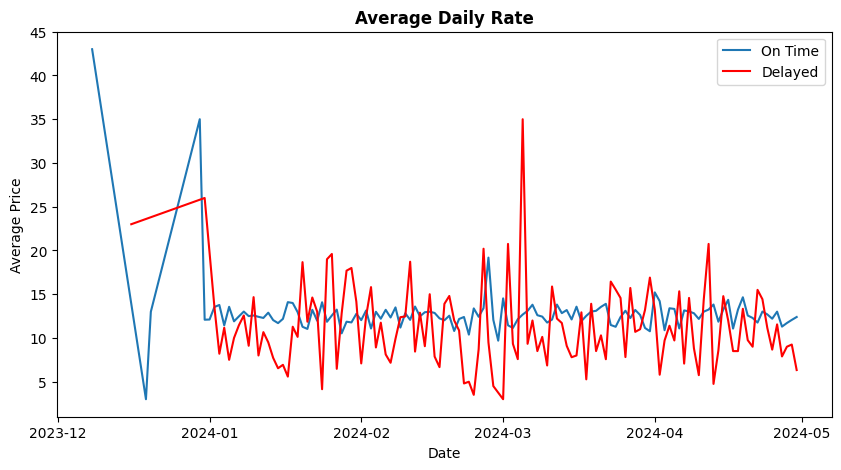

In [145]:
plt.figure(figsize=(10,5))
plt.plot(Date_Of_Purchase_OnTime,Price_OnTime,label='On Time')
plt.plot(Date_Of_Purchase_Delayed,Price_Delayed,label='Delayed',color='red')
plt.title('Average Daily Rate',fontdict=({'fontweight':'bold'}))
plt.legend()
plt.xlabel('Date',)
plt.ylabel('Average Price')
plt.show()

In [147]:
Hours = df['Time of Purchase'].dt.hour

In [150]:
Ticket_Purchase_Time = df.groupby(Hours).agg({'Transaction ID':'count'}).sort_values(by='Transaction ID',ascending=False).reset_index()

In [151]:
Ticket_Purchase_Hours = Ticket_Purchase_Time['Time of Purchase']
NO_Of_Customers = Ticket_Purchase_Time['Transaction ID']

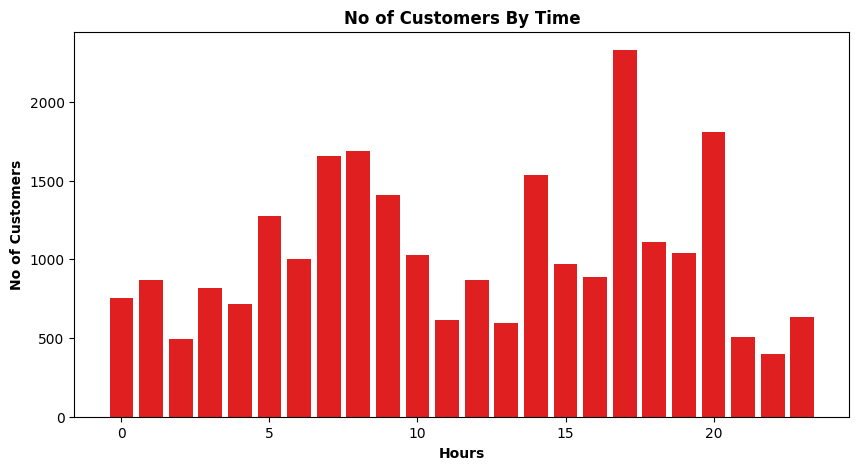

In [160]:
plt.figure(figsize=(10,5))
plt.bar(Ticket_Purchase_Hours,NO_Of_Customers,label='Hours',color='#e01f20')
plt.title('No of Customers By Time',fontdict=({'fontweight':'bold'}))
plt.xlabel('Hours',fontdict=({'fontweight':'bold'}))
plt.ylabel('No of Customers',fontdict=({'fontweight':'bold'}))
plt.show()